# Equipo 5
Luis Ruben Sosa Delgadillo

Susana Suastegui Rodriguez

Andrea Esther Aranda López

Eduardo Ronson García

# Proyecto: Rendimiento académico de estudiantes

En este proyecto se analiza el rendimiento de los estudiantes a partir de sus horas de estudio y del puntaje total que obtuvieron.

### Preguntas de investigación

1. ¿Los puntajes totales del dataset tienen una distribución normal?
2. ¿Hay una diferencia significativa entre el puntaje promedio de quienes estudian **15 horas o más por semana** y quienes estudian **menos de 15 horas**?

### Dataset utilizado

**Archivo:** `student_performance.csv`

El archivo contiene 500,000 registros y estas variables:

| Variable | Descripción |
|---|---|
| `student_id` | Identificador de cada estudiante |
| `weekly_self_study_hours` | Horas de estudio por semana |
| `attendance_percentage` | Porcentaje de asistencia |
| `class_participation` | Participación en clase |
| `total_score` | Puntaje total, de 0 a 100 |
| `grade` | Calificación: `A`, `B`, `C`, `D` o `F` |

La variable principal será `total_score`. Para hacer la comparación se dividieron los estudiantes en dos grupos usando 15 horas semanales como corte, ya que este valor está cerca de la mediana del dataset.

### Métodos que se van a utilizar

- Ajuste de una distribución normal.
- Estimación de la media y la desviación estándar por máxima verosimilitud.
- Intervalos de confianza del 95%.
- Pruebas de Shapiro–Wilk, D’Agostino–Pearson y Anderson–Darling.
- Prueba t de Welch para comparar las medias.
- Tamaño del efecto con $d$ de Cohen.
- Prueba de Mann–Whitney como apoyo para la comparación.

Se trabajará con un nivel de significancia de:

$$
\alpha=0.05
$$

## 1. Librerías que se van a utilizar

In [1]:
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ALPHA = 0.05
NIVEL_CONFIANZA = 0.95
SEMILLA = 12345
UMBRAL_HORAS = 15.0
GRUPO_ALTO = f"{UMBRAL_HORAS:g} horas o más"
GRUPO_BAJO = f"Menos de {UMBRAL_HORAS:g} horas"

def formatear_p(valor):
    """Da formato a los p-valores muy pequeños para que no aparezcan como cero."""
    return "< 1e-300" if float(valor) == 0.0 else f"= {float(valor):.6g}"


## 2. Lectura del dataset

El archivo se encuentra en el repositorio de GitHub
`andrea-aranda-lop/Diplomado-Modulo-2`.

Primero se intenta cargar directamente desde GitHub. Si no hay conexión, el código busca el CSV en la misma carpeta del notebook. También considera el nombre con `(1)`, que suele aparecer cuando el archivo se descarga más de una vez.

In [2]:
URL_DATOS = (
    "https://raw.githubusercontent.com/"
    "andrea-aranda-lop/Diplomado-Modulo-2/"
    "main/student_performance.csv"
)

archivos_locales = [
    Path("student_performance.csv"),
    Path("student_performance(1).csv"),
]

fuente_utilizada = None
error_github = None

try:
    datos_originales = pd.read_csv(URL_DATOS)
    fuente_utilizada = URL_DATOS
except Exception as error:
    error_github = error
    for archivo in archivos_locales:
        if archivo.exists():
            datos_originales = pd.read_csv(archivo)
            fuente_utilizada = str(archivo.resolve())
            break
    else:
        raise ConnectionError(
            "No fue posible descargar la base desde GitHub ni encontrar "
            "student_performance.csv en la carpeta del notebook."
        ) from error_github

print("Fuente utilizada:", fuente_utilizada)
print("Dimensión original:", datos_originales.shape)
datos_originales.head()

Fuente utilizada: https://raw.githubusercontent.com/andrea-aranda-lop/Diplomado-Modulo-2/main/student_performance.csv
Dimensión original: (500000, 6)


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5000,95.6000,3.8000,97.9000,A
1,2,14.0000,80.0000,2.5000,83.9000,B
2,3,19.5000,86.3000,5.3000,100.0000,A
3,4,25.7000,70.2000,7.0000,100.0000,A
4,5,13.4000,81.9000,6.9000,92.0000,A


## 3. Revisión y limpieza de los datos

Antes de comenzar con el análisis se revisan algunos puntos básicos:

- Que estén todas las columnas necesarias.
- El tipo de dato de cada columna.
- Si existen valores faltantes.
- Las categorías de las calificaciones.
- Si hay identificadores repetidos.
- Si existen filas completamente duplicadas.
- Que las horas, la asistencia, la participación y el puntaje estén dentro de rangos válidos.

In [3]:
print("Columnas:")
print(datos_originales.columns.tolist())

print("\nTipos de datos:")
print(datos_originales.dtypes)

print("\nValores faltantes:")
print(datos_originales.isna().sum())

print("\nDuplicados completos:")
print(datos_originales.duplicated().sum())

if "student_id" in datos_originales.columns:
    print("\nIdentificadores duplicados:")
    print(datos_originales["student_id"].duplicated().sum())

if "grade" in datos_originales.columns:
    print("\nCategorías originales de grade:")
    print(datos_originales["grade"].value_counts(dropna=False).sort_index())

Columnas:
['student_id', 'weekly_self_study_hours', 'attendance_percentage', 'class_participation', 'total_score', 'grade']

Tipos de datos:
student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                          str
dtype: object

Valores faltantes:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Duplicados completos:
0

Identificadores duplicados:
0

Categorías originales de grade:
grade
A    274151
B    129399
C     70731
D     22571
F      3148
Name: count, dtype: int64


In [4]:
columnas_requeridas = {
    "student_id",
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score",
    "grade",
}
columnas_faltantes = columnas_requeridas - set(datos_originales.columns)

if columnas_faltantes:
    raise KeyError(
        f"El archivo no contiene las columnas necesarias: {columnas_faltantes}"
    )

datos = datos_originales.copy()

columnas_numericas = [
    "student_id",
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score",
]

for columna in columnas_numericas:
    datos[columna] = pd.to_numeric(datos[columna], errors="coerce")

datos["grade"] = datos["grade"].astype("string").str.strip().str.upper()
calificaciones_validas = {"A", "B", "C", "D", "F"}

mascara_valida = (
    datos["student_id"].notna()
    & (datos["student_id"] > 0)
    & datos["weekly_self_study_hours"].notna()
    & (datos["weekly_self_study_hours"] >= 0)
    & datos["attendance_percentage"].between(0, 100, inclusive="both")
    & datos["class_participation"].between(0, 10, inclusive="both")
    & datos["total_score"].between(0, 100, inclusive="both")
    & datos["grade"].isin(calificaciones_validas)
)

datos_limpios = datos.loc[mascara_valida].copy()

datos_limpios = datos_limpios.rename(
    columns={
        "student_id": "id_estudiante",
        "weekly_self_study_hours": "horas_estudio_semanal",
        "attendance_percentage": "porcentaje_asistencia",
        "class_participation": "participacion_clase",
        "total_score": "puntaje_total",
        "grade": "calificacion",
    }
)

datos_limpios["grupo_estudio"] = np.where(
    datos_limpios["horas_estudio_semanal"] >= UMBRAL_HORAS,
    GRUPO_ALTO,
    GRUPO_BAJO,
)

print("Registros originales:", len(datos_originales))
print("Registros válidos:", len(datos_limpios))
print("Registros excluidos:", len(datos_originales) - len(datos_limpios))
print("Mediana de horas de estudio:", datos_limpios["horas_estudio_semanal"].median())

datos_limpios.head()

Registros originales: 500000
Registros válidos: 500000
Registros excluidos: 0
Mediana de horas de estudio: 15.0


,id_estudiante,horas_estudio_semanal,porcentaje_asistencia,participacion_clase,puntaje_total,calificacion,grupo_estudio
0,1,18.5000,95.6000,3.8000,97.9000,A,15 horas o más
1,2,14.0000,80.0000,2.5000,83.9000,B,Menos de 15 horas
2,3,19.5000,86.3000,5.3000,100.0000,A,15 horas o más
3,4,25.7000,70.2000,7.0000,100.0000,A,15 horas o más
4,5,13.4000,81.9000,6.9000,92.0000,A,Menos de 15 horas


In [5]:
variables_control = [
    "horas_estudio_semanal",
    "porcentaje_asistencia",
    "participacion_clase",
    "puntaje_total",
]

control_calidad = pd.DataFrame(
    {
        "variable": variables_control,
        "n": [datos_limpios[c].count() for c in variables_control],
        "faltantes": [datos_limpios[c].isna().sum() for c in variables_control],
        "mínimo": [datos_limpios[c].min() for c in variables_control],
        "máximo": [datos_limpios[c].max() for c in variables_control],
    }
)

control_calidad

,variable,n,faltantes,mínimo,máximo
0,horas_estudio_semanal,500000,0,0.0000,40.0000
1,porcentaje_asistencia,500000,0,50.0000,100.0000
2,participacion_clase,500000,0,0.0000,10.0000
3,puntaje_total,500000,0,9.4000,100.0000


### Resultado de la limpieza

Después de revisar el archivo, no se encontraron valores faltantes ni datos fuera de los rangos definidos. Por esta razón se pueden utilizar los 500,000 registros.

Tampoco se eliminan filas solo porque algunos estudiantes tengan los mismos valores académicos, ya que cada uno tiene su propio identificador. Lo importante en este caso es comprobar que `student_id` no esté repetido.

## 4. Descripción general de los datos

In [6]:
frecuencias_calificacion = (
    datos_limpios["calificacion"]
    .value_counts()
    .sort_index()
    .rename_axis("calificacion")
    .to_frame("frecuencia")
)
frecuencias_calificacion["porcentaje"] = (
    100
    * frecuencias_calificacion["frecuencia"]
    / frecuencias_calificacion["frecuencia"].sum()
)

frecuencias_grupo_estudio = (
    datos_limpios["grupo_estudio"]
    .value_counts()
    .reindex([GRUPO_ALTO, GRUPO_BAJO])
    .rename_axis("grupo_estudio")
    .to_frame("frecuencia")
)
frecuencias_grupo_estudio["porcentaje"] = (
    100
    * frecuencias_grupo_estudio["frecuencia"]
    / frecuencias_grupo_estudio["frecuencia"].sum()
)

print("Distribución por calificación:")
display(frecuencias_calificacion)
print("Distribución por grupo de estudio:")
display(frecuencias_grupo_estudio)

Distribución por calificación:


,frecuencia,porcentaje
calificacion,,
A,274151,54.8302
B,129399,25.8798
C,70731,14.1462
D,22571,4.5142
F,3148,0.6296


Distribución por grupo de estudio:


,frecuencia,porcentaje
grupo_estudio,,
15 horas o más,251193,50.2386
Menos de 15 horas,248807,49.7614


In [7]:
resumen_general = pd.DataFrame(
    {
        "n": [datos_limpios["puntaje_total"].count()],
        "media_puntaje": [datos_limpios["puntaje_total"].mean()],
        "mediana_puntaje": [datos_limpios["puntaje_total"].median()],
        "desviacion_estandar": [datos_limpios["puntaje_total"].std(ddof=1)],
        "minimo": [datos_limpios["puntaje_total"].min()],
        "maximo": [datos_limpios["puntaje_total"].max()],
        "media_horas_estudio": [datos_limpios["horas_estudio_semanal"].mean()],
        "media_asistencia": [datos_limpios["porcentaje_asistencia"].mean()],
    },
    index=["Total"],
)

resumen_por_grupo = (
    datos_limpios.groupby("grupo_estudio", observed=True)
    .agg(
        n=("puntaje_total", "size"),
        media_puntaje=("puntaje_total", "mean"),
        mediana_puntaje=("puntaje_total", "median"),
        desviacion_estandar=("puntaje_total", "std"),
        minimo=("puntaje_total", "min"),
        maximo=("puntaje_total", "max"),
        media_horas_estudio=("horas_estudio_semanal", "mean"),
        media_asistencia=("porcentaje_asistencia", "mean"),
    )
    .reindex([GRUPO_ALTO, GRUPO_BAJO])
)

tabla_descriptiva = pd.concat([resumen_general, resumen_por_grupo])
tabla_descriptiva

,n,media_puntaje,mediana_puntaje,desviacion_estandar,minimo,maximo,media_horas_estudio,media_asistencia
Total,500000,84.2805,87.5000,15.4383,9.4000,100.0000,15.0326,84.7180
15 horas o más,251193,94.9175,100.0000,7.3847,48.3000,100.0000,20.5539,84.7206
Menos de 15 horas,248807,73.5414,74.5000,13.9410,9.4000,100.0000,9.4584,84.7155


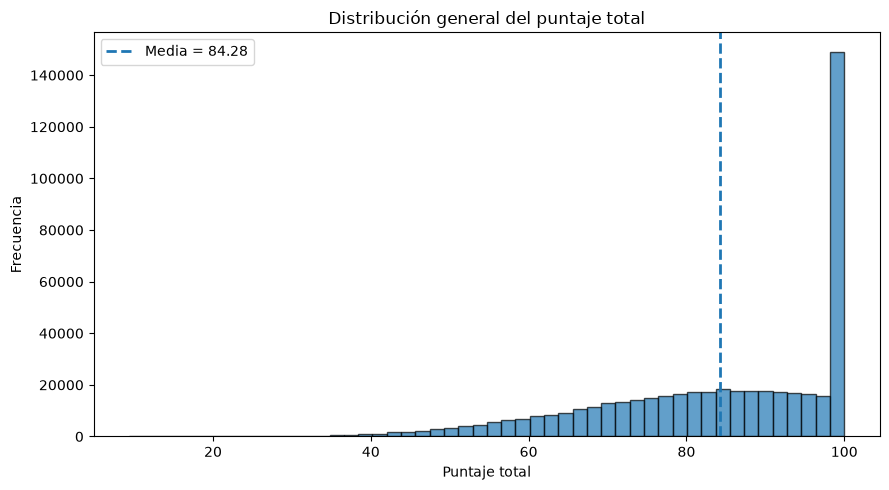

In [8]:
# Primero revisamos cómo se distribuyen todos los puntajes.
plt.figure(figsize=(9, 5))
plt.hist(
    datos_limpios["puntaje_total"],
    bins=50,
    edgecolor="black",
    alpha=0.70,
)
plt.axvline(
    datos_limpios["puntaje_total"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {datos_limpios['puntaje_total'].mean():.2f}",
)
plt.title("Distribución general del puntaje total")
plt.xlabel("Puntaje total")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

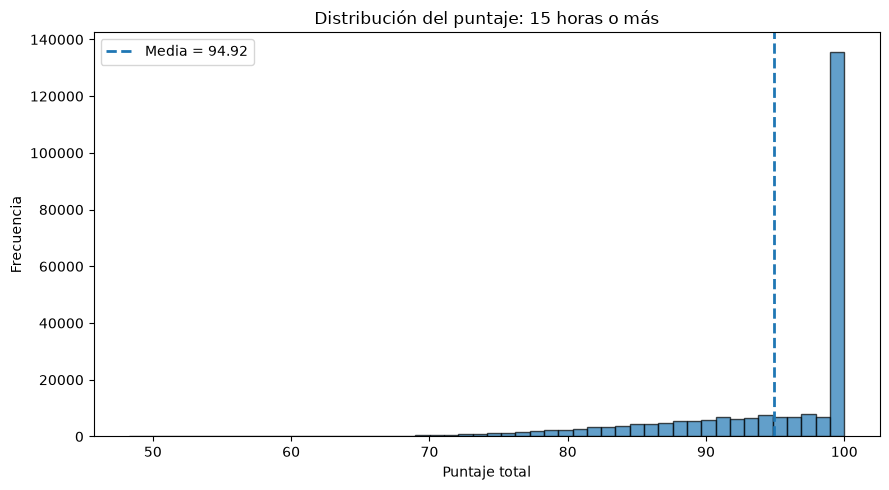

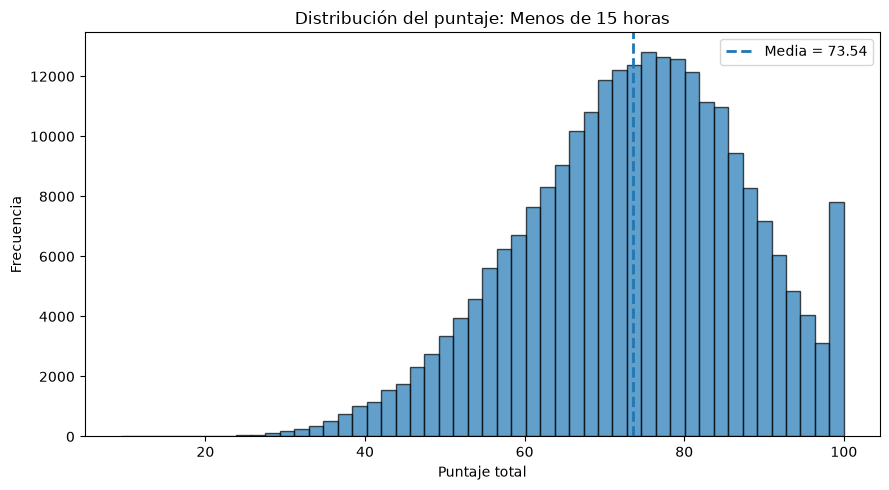

In [9]:
# Ahora vemos la distribución por separado para cada grupo.
for grupo in [GRUPO_ALTO, GRUPO_BAJO]:
    subconjunto = datos_limpios.loc[
        datos_limpios["grupo_estudio"] == grupo
    ]
    plt.figure(figsize=(9, 5))
    plt.hist(
        subconjunto["puntaje_total"],
        bins=50,
        edgecolor="black",
        alpha=0.70,
    )
    plt.axvline(
        subconjunto["puntaje_total"].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Media = {subconjunto['puntaje_total'].mean():.2f}",
    )
    plt.title(f"Distribución del puntaje: {grupo}")
    plt.xlabel("Puntaje total")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

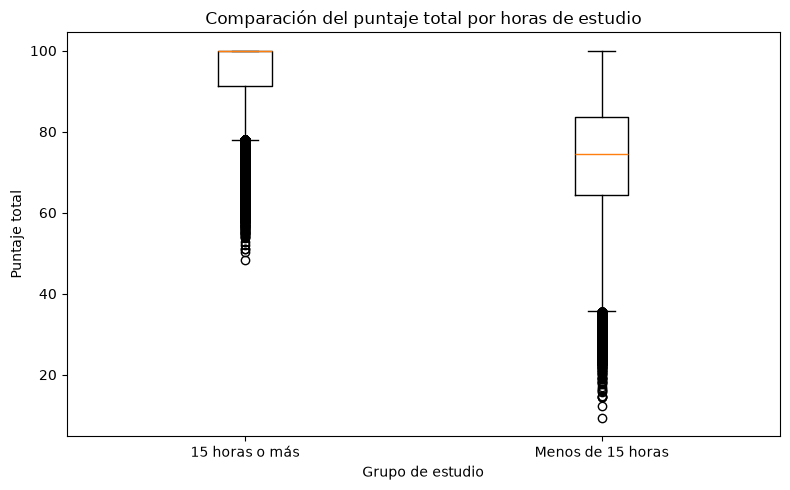

In [10]:
# El boxplot permite comparar rápidamente los dos grupos.
grupos_boxplot = [
    datos_limpios.loc[
        datos_limpios["grupo_estudio"] == GRUPO_ALTO,
        "puntaje_total",
    ],
    datos_limpios.loc[
        datos_limpios["grupo_estudio"] == GRUPO_BAJO,
        "puntaje_total",
    ],
]

plt.figure(figsize=(8, 5))
plt.boxplot(grupos_boxplot, tick_labels=[GRUPO_ALTO, GRUPO_BAJO])
plt.title("Comparación del puntaje total por horas de estudio")
plt.xlabel("Grupo de estudio")
plt.ylabel("Puntaje total")
plt.tight_layout()
plt.show()

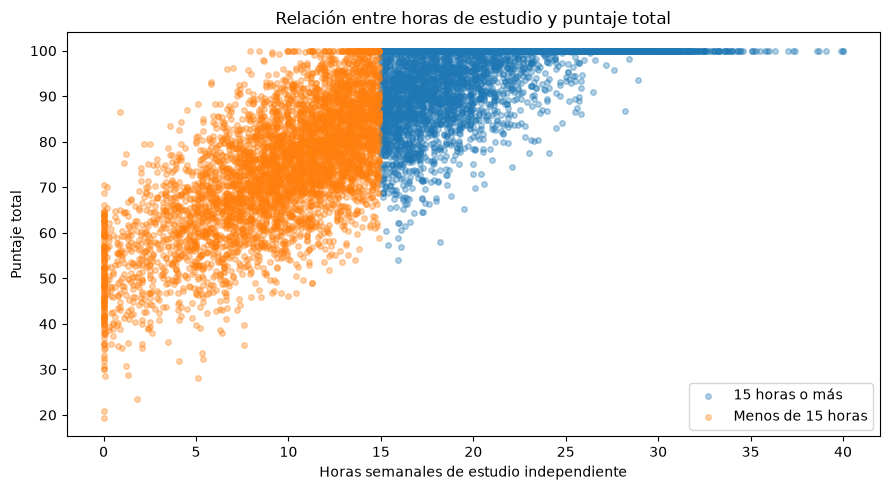

Correlación de Pearson = 0.8120


In [11]:
# Revisamos la relación entre las horas de estudio y el puntaje.
# Solo se grafican 10,000 casos para que los puntos no se encimen.
n_muestra_grafica = min(10_000, len(datos_limpios))
muestra_grafica = datos_limpios.sample(
    n=n_muestra_grafica,
    random_state=SEMILLA,
)

plt.figure(figsize=(9, 5))
for grupo in [GRUPO_ALTO, GRUPO_BAJO]:
    subconjunto = muestra_grafica.loc[
        muestra_grafica["grupo_estudio"] == grupo
    ]
    plt.scatter(
        subconjunto["horas_estudio_semanal"],
        subconjunto["puntaje_total"],
        alpha=0.35,
        s=16,
        label=grupo,
    )

plt.title("Relación entre horas de estudio y puntaje total")
plt.xlabel("Horas semanales de estudio independiente")
plt.ylabel("Puntaje total")
plt.legend()
plt.tight_layout()
plt.show()

correlacion = datos_limpios[
    ["horas_estudio_semanal", "puntaje_total"]
].corr().iloc[0, 1]
print(f"Correlación de Pearson = {correlacion:.4f}")

## 5. Distribución que se va a analizar

El puntaje total es una variable numérica que va de 0 a 100.

Como punto de partida se propone una distribución normal:

$$
X\sim N(\mu,\sigma^2)
$$

Su función de densidad es:

$$
f(x\mid\mu,\sigma)
=
\frac{1}{\sigma\sqrt{2\pi}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right),
\qquad \sigma>0.
$$

Se toma la normal como una primera referencia porque el rendimiento escolar puede depender de varios factores al mismo tiempo. Sin embargo, aquí hay un detalle importante: los puntajes no pueden ser menores que 0 ni mayores que 100, y varios estudiantes llegan justamente a 100.

Por eso no se dará por hecho que los datos son normales. Esto se revisará con histogramas, gráficos Q–Q y pruebas de normalidad.

## 6. Estimación por máxima verosimilitud

Suponiendo que se tiene una muestra:

$$
X_1,\ldots,X_n\overset{iid}{\sim}N(\mu,\sigma^2),
$$

la función de verosimilitud es:

$$
L(\mu,\sigma^2)
=
\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left[
-\frac{(x_i-\mu)^2}{2\sigma^2}
\right].
$$

Los estimadores de máxima verosimilitud son:

$$
\widehat{\mu}_{MLE}
=
\bar{x}
=
\frac{1}{n}\sum_{i=1}^{n}x_i
$$

y

$$
\widehat{\sigma}_{MLE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}.
$$

En el caso de $\widehat{\sigma}_{MLE}$ se divide entre $n$, no entre $n-1$.

In [12]:
def estimadores_mle_normal(valores):
    """Calcula la media y la desviación estándar por máxima verosimilitud."""
    x = pd.Series(valores).dropna().astype(float).to_numpy()

    if len(x) == 0:
        raise ValueError("No hay observaciones disponibles.")

    return pd.Series(
        {
            "n": len(x),
            "mu_MLE": np.mean(x),
            "sigma_MLE": np.std(x, ddof=0),
            "varianza_MLE": np.var(x, ddof=0),
            "desviacion_muestral": np.std(x, ddof=1),
        }
    )


estimaciones = {
    "Total": estimadores_mle_normal(datos_limpios["puntaje_total"])
}

for grupo in [GRUPO_ALTO, GRUPO_BAJO]:
    estimaciones[grupo] = estimadores_mle_normal(
        datos_limpios.loc[
            datos_limpios["grupo_estudio"] == grupo,
            "puntaje_total",
        ]
    )

tabla_mle = pd.DataFrame(estimaciones).T
tabla_mle

,n,mu_MLE,sigma_MLE,varianza_MLE,desviacion_muestral
Total,"500,000.0000",84.2805,15.4383,238.3408,15.4383
15 horas o más,"251,193.0000",94.9175,7.3847,54.5338,7.3847
Menos de 15 horas,"248,807.0000",73.5414,13.9410,194.3517,13.9410


In [13]:
for grupo, fila in tabla_mle.iterrows():
    print(
        f"{grupo}: μ̂_MLE = {fila['mu_MLE']:.2f} puntos y "
        f"σ̂_MLE = {fila['sigma_MLE']:.2f} puntos."
    )

Total: μ̂_MLE = 84.28 puntos y σ̂_MLE = 15.44 puntos.
15 horas o más: μ̂_MLE = 94.92 puntos y σ̂_MLE = 7.38 puntos.
Menos de 15 horas: μ̂_MLE = 73.54 puntos y σ̂_MLE = 13.94 puntos.


### ¿Qué significan estos resultados?

- $\widehat{\mu}_{MLE}$ es el promedio estimado de los puntajes.
- $\widehat{\sigma}_{MLE}$ muestra qué tanto se separan los puntajes de ese promedio.
- Estos valores se pueden calcular aunque los datos no sean completamente normales. Más adelante se revisará qué tan bien se ajusta la normal a los puntajes reales.

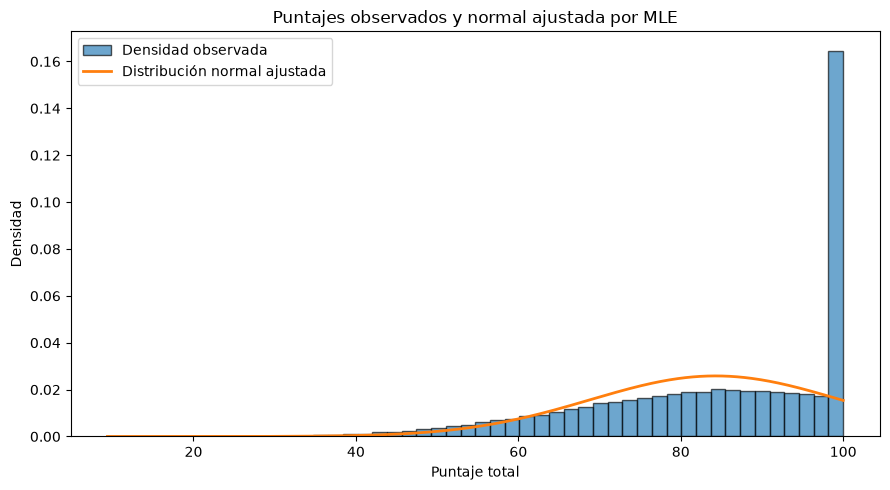

In [14]:
# Comparamos los datos reales con la normal que se ajustó.
x = datos_limpios["puntaje_total"].to_numpy()
mu_mle = np.mean(x)
sigma_mle = np.std(x, ddof=0)

eje_x = np.linspace(x.min(), x.max(), 500)
densidad_normal = stats.norm.pdf(
    eje_x,
    loc=mu_mle,
    scale=sigma_mle,
)

plt.figure(figsize=(9, 5))
plt.hist(
    x,
    bins=50,
    density=True,
    edgecolor="black",
    alpha=0.65,
    label="Densidad observada",
)
plt.plot(
    eje_x,
    densidad_normal,
    linewidth=2,
    label="Distribución normal ajustada",
)
plt.title("Puntajes observados y normal ajustada por MLE")
plt.xlabel("Puntaje total")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Intervalos de confianza del 95% para las medias

Como no conocemos la desviación estándar de toda la población, se usa el intervalo:

$$
\bar{x}
\pm
t_{\alpha/2,n-1}
\frac{s}{\sqrt{n}}.
$$

La idea del intervalo de confianza es que, si se repitiera el mismo procedimiento con muchas muestras, cerca del 95% de los intervalos incluirían la media real de la población.

En este dataset hay cientos de miles de observaciones por grupo. Esto hace que las medias se puedan estimar con bastante precisión, aunque los puntajes individuales no sigan una distribución normal. También hay que recordar que un resultado puede ser estadísticamente significativo solo por tener una muestra muy grande, así que después se revisará el tamaño real de la diferencia.

In [15]:
def intervalo_confianza_media(valores, confianza=0.95):
    """Calcula el intervalo de confianza para una media."""
    x = pd.Series(valores).dropna().astype(float).to_numpy()
    n = len(x)

    if n < 2:
        raise ValueError("Se requieren al menos dos observaciones.")

    media = np.mean(x)
    s = np.std(x, ddof=1)
    error_estandar = s / np.sqrt(n)
    gl = n - 1
    valor_critico = stats.t.ppf((1 + confianza) / 2, df=gl)
    margen = valor_critico * error_estandar

    return pd.Series(
        {
            "n": n,
            "media": media,
            "error_estandar": error_estandar,
            "grados_libertad": gl,
            "limite_inferior_95": media - margen,
            "limite_superior_95": media + margen,
            "margen_error": margen,
        }
    )


intervalos = {
    "Total": intervalo_confianza_media(datos_limpios["puntaje_total"])
}

for grupo in [GRUPO_ALTO, GRUPO_BAJO]:
    intervalos[grupo] = intervalo_confianza_media(
        datos_limpios.loc[
            datos_limpios["grupo_estudio"] == grupo,
            "puntaje_total",
        ]
    )

tabla_intervalos = pd.DataFrame(intervalos).T
tabla_intervalos

,n,media,error_estandar,grados_libertad,limite_inferior_95,limite_superior_95,margen_error
Total,"500,000.0000",84.2805,0.0218,"499,999.0000",84.2377,84.3233,0.0428
15 horas o más,"251,193.0000",94.9175,0.0147,"251,192.0000",94.8886,94.9464,0.0289
Menos de 15 horas,"248,807.0000",73.5414,0.0279,"248,806.0000",73.4867,73.5962,0.0548


In [16]:
for grupo, fila in tabla_intervalos.iterrows():
    print(
        f"{grupo}: media = {fila['media']:.2f} puntos; "
        f"IC 95% = [{fila['limite_inferior_95']:.2f}, "
        f"{fila['limite_superior_95']:.2f}] puntos."
    )

Total: media = 84.28 puntos; IC 95% = [84.24, 84.32] puntos.
15 horas o más: media = 94.92 puntos; IC 95% = [94.89, 94.95] puntos.
Menos de 15 horas: media = 73.54 puntos; IC 95% = [73.49, 73.60] puntos.


## 8. Pruebas de normalidad

Para Shapiro–Wilk y D’Agostino–Pearson se plantean estas hipótesis:

$$
H_0:\text{los puntajes siguen una distribución normal}
$$

$$
H_a:\text{los puntajes no siguen una distribución normal}
$$

La decisión se toma de esta manera:

- Si $p<0.05$, se rechaza $H_0$.
- Si $p\geq0.05$, no hay evidencia suficiente para rechazar $H_0$.

En Anderson–Darling se compara el estadístico con el valor crítico del 5%:

- Si $A^2>A^2_{\text{crítico}}$, se rechaza la normalidad.
- Si $A^2\leq A^2_{\text{crítico}}$, no se rechaza.

Shapiro–Wilk puede ser demasiado sensible y generar advertencias con una base tan grande. Por eso se aplica sobre una muestra aleatoria de hasta 5,000 datos. D’Agostino–Pearson y Anderson–Darling sí se calculan con todos los registros. Los resultados también se comparan con los histogramas y los gráficos Q–Q.

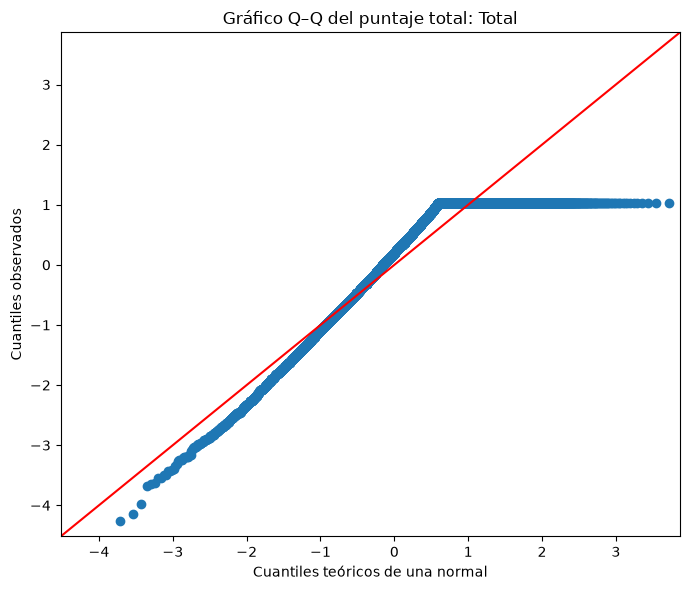

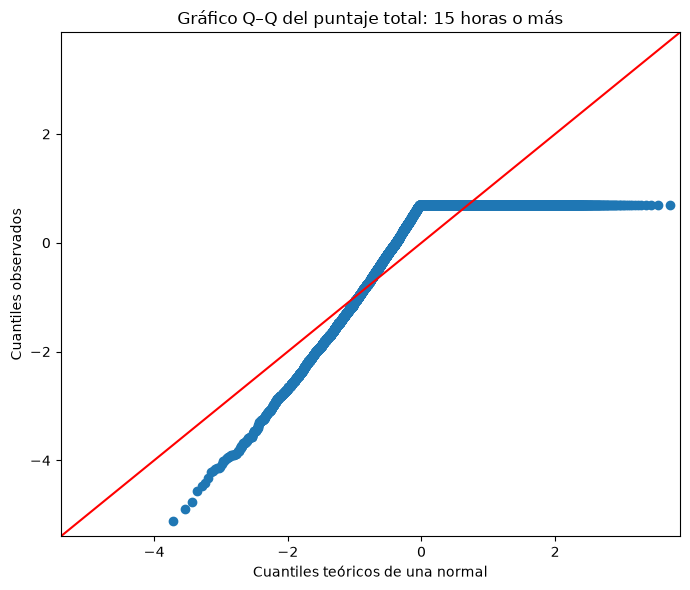

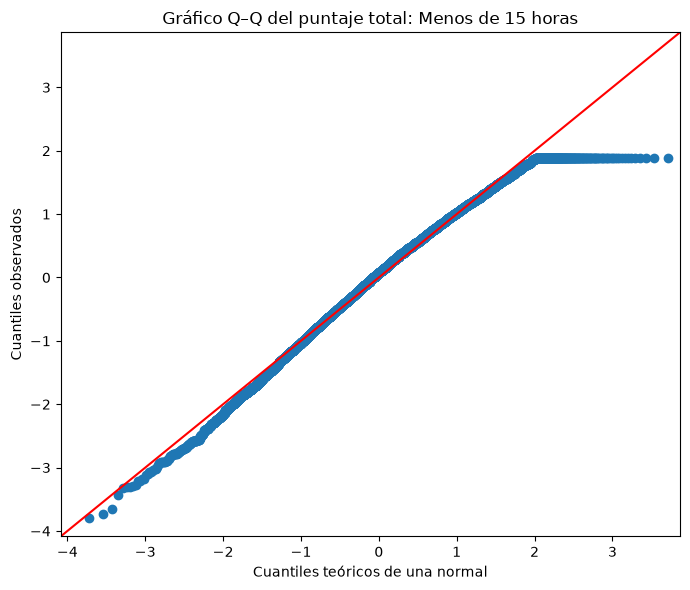

In [17]:
grupos_qq = {
    "Total": datos_limpios["puntaje_total"]
}

for grupo in [GRUPO_ALTO, GRUPO_BAJO]:
    grupos_qq[grupo] = datos_limpios.loc[
        datos_limpios["grupo_estudio"] == grupo,
        "puntaje_total",
    ]

for nombre, valores in grupos_qq.items():
    valores_qq = pd.Series(valores).dropna()
    muestra_qq = valores_qq.sample(
        n=min(10_000, len(valores_qq)),
        random_state=SEMILLA,
    )

    plt.figure(figsize=(7, 6))
    sm.qqplot(
        muestra_qq,
        line="45",
        fit=True,
        ax=plt.gca(),
    )
    plt.title(f"Gráfico Q–Q del puntaje total: {nombre}")
    plt.xlabel("Cuantiles teóricos de una normal")
    plt.ylabel("Cuantiles observados")
    plt.tight_layout()
    plt.show()

In [18]:
def pruebas_normalidad(valores, alpha=0.05, semilla=12345):
    """Ejecuta las pruebas de normalidad y calcula asimetría y curtosis."""
    x = pd.Series(valores).dropna().astype(float).to_numpy()

    if len(x) < 8:
        raise ValueError(
            "D'Agostino-Pearson requiere al menos ocho observaciones."
        )

    rng = np.random.default_rng(semilla)
    n_shapiro = min(5_000, len(x))
    muestra_shapiro = rng.choice(x, size=n_shapiro, replace=False)

    w_shapiro, p_shapiro = stats.shapiro(muestra_shapiro)
    k2_dagostino, p_dagostino = stats.normaltest(x)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        resultado_ad = stats.anderson(x, dist="norm")
    posicion_5 = int(
        np.argmin(np.abs(resultado_ad.significance_level - 5.0))
    )
    critico_ad_5 = resultado_ad.critical_values[posicion_5]
    rechaza_ad = resultado_ad.statistic > critico_ad_5

    return pd.Series(
        {
            "n_total": len(x),
            "n_shapiro": n_shapiro,
            "W_shapiro": w_shapiro,
            "p_shapiro": p_shapiro,
            "decision_shapiro": (
                "Rechazar normalidad"
                if p_shapiro < alpha
                else "No rechazar normalidad"
            ),
            "K2_dagostino": k2_dagostino,
            "p_dagostino": p_dagostino,
            "decision_dagostino": (
                "Rechazar normalidad"
                if p_dagostino < alpha
                else "No rechazar normalidad"
            ),
            "AD_estadistico": resultado_ad.statistic,
            "AD_critico_5pct": critico_ad_5,
            "decision_anderson": (
                "Rechazar normalidad"
                if rechaza_ad
                else "No rechazar normalidad"
            ),
            "asimetria": stats.skew(x, bias=False),
            "curtosis_exceso": stats.kurtosis(
                x,
                fisher=True,
                bias=False,
            ),
        }
    )


resultados_normalidad = {
    "Total": pruebas_normalidad(
        datos_limpios["puntaje_total"],
        semilla=SEMILLA,
    )
}

for i, grupo in enumerate([GRUPO_ALTO, GRUPO_BAJO], start=1):
    resultados_normalidad[grupo] = pruebas_normalidad(
        datos_limpios.loc[
            datos_limpios["grupo_estudio"] == grupo,
            "puntaje_total",
        ],
        semilla=SEMILLA + i,
    )

tabla_normalidad = pd.DataFrame(resultados_normalidad).T
tabla_normalidad

,n_total,n_shapiro,W_shapiro,p_shapiro,decision_shapiro,K2_dagostino,p_dagostino,decision_dagostino,AD_estadistico,AD_critico_5pct,decision_anderson,asimetria,curtosis_exceso
Total,500000,5000,0.8859,0.0000,Rechazar normalidad,"43,665.2821",0.0000,Rechazar normalidad,"16,636.8897",0.7520,Rechazar normalidad,-0.8195,-0.1047
15 horas o más,251193,5000,0.7338,0.0000,Rechazar normalidad,"65,271.6314",0.0000,Rechazar normalidad,"26,029.2678",0.7520,Rechazar normalidad,-1.5473,1.8923
Menos de 15 horas,248807,5000,0.9887,0.0000,Rechazar normalidad,"4,883.6861",0.0000,Rechazar normalidad,443.0230,0.7520,Rechazar normalidad,-0.3331,-0.2006


In [19]:
for grupo, fila in tabla_normalidad.iterrows():
    print(f"\n{grupo}")
    print(
        f"Shapiro–Wilk (n={int(fila['n_shapiro'])}): "
        f"W={fila['W_shapiro']:.4f}, "
        f"p {formatear_p(fila['p_shapiro'])}. "
        f"{fila['decision_shapiro']}."
    )
    print(
        f"D’Agostino–Pearson: K²={fila['K2_dagostino']:.4f}, "
        f"p {formatear_p(fila['p_dagostino'])}. "
        f"{fila['decision_dagostino']}."
    )
    print(
        f"Anderson–Darling: A²={fila['AD_estadistico']:.4f}, "
        f"crítico 5%={fila['AD_critico_5pct']:.4f}. "
        f"{fila['decision_anderson']}."
    )


Total
Shapiro–Wilk (n=5000): W=0.8859, p = 1.88703e-51. Rechazar normalidad.
D’Agostino–Pearson: K²=43665.2821, p < 1e-300. Rechazar normalidad.
Anderson–Darling: A²=16636.8897, crítico 5%=0.7520. Rechazar normalidad.

15 horas o más
Shapiro–Wilk (n=5000): W=0.7338, p = 4.14645e-67. Rechazar normalidad.
D’Agostino–Pearson: K²=65271.6314, p < 1e-300. Rechazar normalidad.
Anderson–Darling: A²=26029.2678, crítico 5%=0.7520. Rechazar normalidad.

Menos de 15 horas
Shapiro–Wilk (n=5000): W=0.9887, p = 1.53024e-19. Rechazar normalidad.
D’Agostino–Pearson: K²=4883.6861, p < 1e-300. Rechazar normalidad.
Anderson–Darling: A²=443.0230, crítico 5%=0.7520. Rechazar normalidad.


### Lo que se observa en la forma de los datos

Una distribución normal debería verse más o menos simétrica y con forma de campana. En este caso, los puntajes se cargan hacia los valores altos y hay muchos registros exactamente en 100. Esto se conoce como efecto techo.

Como los datos ya no pueden seguir aumentando después de 100, la parte superior de la distribución queda cortada. Por eso los histogramas, los gráficos Q–Q y las pruebas muestran que la normal no representa bien toda la distribución.

## 9. Comparación de las medias

Ahora se quiere revisar si el promedio cambia entre los estudiantes que estudian 15 horas o más por semana y los que estudian menos de 15 horas.

Se definen:

- $\mu_{15+}$: promedio de quienes estudian 15 horas o más.
- $\mu_{<15}$: promedio de quienes estudian menos de 15 horas.

Las hipótesis son:

$$
H_0:\mu_{15+}=\mu_{<15}
$$

$$
H_a:\mu_{15+}\neq\mu_{<15}
$$

También se pueden escribir como:

$$
H_0:\mu_{15+}-\mu_{<15}=0
$$

$$
H_a:\mu_{15+}-\mu_{<15}\neq0.
$$

Para compararlas se usa la **prueba t de Welch**:

$$
t
=
\frac{\bar{x}_{15+}-\bar{x}_{<15}}
{
\sqrt{
\frac{s_{15+}^2}{n_{15+}}
+
\frac{s_{<15}^2}{n_{<15}}
}
}.
$$

Se eligió Welch porque no necesita suponer que los dos grupos tienen la misma varianza. Además, como ambos grupos tienen una gran cantidad de registros, la comparación de las medias sigue siendo útil aunque los puntajes no sean normales.

In [20]:
grupo_15_mas = (
    datos_limpios.loc[
        datos_limpios["grupo_estudio"] == GRUPO_ALTO,
        "puntaje_total",
    ]
    .astype(float)
    .to_numpy()
)

grupo_menos_15 = (
    datos_limpios.loc[
        datos_limpios["grupo_estudio"] == GRUPO_BAJO,
        "puntaje_total",
    ]
    .astype(float)
    .to_numpy()
)

print(f"Número de estudiantes ({GRUPO_ALTO}):", len(grupo_15_mas))
print(f"Número de estudiantes ({GRUPO_BAJO}):", len(grupo_menos_15))
print(f"Media ({GRUPO_ALTO}):", grupo_15_mas.mean())
print(f"Media ({GRUPO_BAJO}):", grupo_menos_15.mean())

Número de estudiantes (15 horas o más): 251193
Número de estudiantes (Menos de 15 horas): 248807
Media (15 horas o más): 94.91752676229034
Media (Menos de 15 horas): 73.5414449754227


In [21]:
# Revisamos si las varianzas de los grupos son parecidas.
estadistico_levene, p_levene = stats.levene(
    grupo_15_mas,
    grupo_menos_15,
    center="median",
)

print(f"Prueba de Levene: estadístico = {estadistico_levene:.4f}")
print(f"p-valor {formatear_p(p_levene)}")

if p_levene < ALPHA:
    print("Las varianzas de los grupos son diferentes.")
else:
    print("No se encontró una diferencia clara entre las varianzas.")

print(
    "De cualquier forma se usa Welch, ya que no necesita que las "
    "varianzas sean iguales."
)

Prueba de Levene: estadístico = 75885.5127
p-valor < 1e-300
Las varianzas de los grupos son diferentes.
De cualquier forma se usa Welch, ya que no necesita que las varianzas sean iguales.


In [22]:
resultado_welch = stats.ttest_ind(
    grupo_15_mas,
    grupo_menos_15,
    equal_var=False,
    alternative="two-sided",
)

t_observado = float(resultado_welch.statistic)
p_valor_welch = float(resultado_welch.pvalue)

print(f"Estadístico t de Welch = {t_observado:.4f}")
print(f"p-valor bilateral {formatear_p(p_valor_welch)}")

if p_valor_welch < ALPHA:
    print(
        "Se rechaza H0: los promedios de los dos grupos son diferentes."
    )
else:
    print(
        "No se rechaza H0: con estos datos no alcanza la evidencia para "
        "decir que los promedios son diferentes."
    )

Estadístico t de Welch = 676.5675
p-valor bilateral < 1e-300
Se rechaza H0: los promedios de los dos grupos son diferentes.


## 10. Intervalo del 95% para la diferencia de medias

La diferencia que se quiere estimar es:

$$
\Delta=\mu_{15+}-\mu_{<15}.
$$

El intervalo de Welch se calcula con:

$$
(\bar{x}_{15+}-\bar{x}_{<15})
\pm
t_{\alpha/2,\nu}
\sqrt{
\frac{s_{15+}^2}{n_{15+}}
+
\frac{s_{<15}^2}{n_{<15}}
}.
$$

Para leer el resultado:

- Si el intervalo incluye el cero, las medias podrían ser iguales.
- Si todo el intervalo es positivo, el grupo de 15 horas o más tiene un promedio mayor.
- Si todo el intervalo es negativo, el grupo de menos de 15 horas tiene un promedio mayor.

In [23]:
def intervalo_diferencia_welch(
    grupo_1,
    grupo_2,
    confianza=0.95,
):
    """Calcula el intervalo de Welch para la diferencia entre dos medias."""
    x1 = np.asarray(grupo_1, dtype=float)
    x2 = np.asarray(grupo_2, dtype=float)

    n1, n2 = len(x1), len(x2)
    media1, media2 = np.mean(x1), np.mean(x2)
    s1, s2 = np.std(x1, ddof=1), np.std(x2, ddof=1)

    termino1 = s1**2 / n1
    termino2 = s2**2 / n2
    error_estandar = np.sqrt(termino1 + termino2)

    gl_welch = (termino1 + termino2) ** 2 / (
        termino1**2 / (n1 - 1)
        + termino2**2 / (n2 - 1)
    )

    diferencia = media1 - media2
    valor_critico = stats.t.ppf(
        (1 + confianza) / 2,
        df=gl_welch,
    )
    margen = valor_critico * error_estandar

    return pd.Series(
        {
            "media_15_horas_o_mas": media1,
            "media_menos_15_horas": media2,
            "diferencia_15_mas_menos_menos_15": diferencia,
            "error_estandar": error_estandar,
            "grados_libertad_welch": gl_welch,
            "limite_inferior_95": diferencia - margen,
            "limite_superior_95": diferencia + margen,
            "margen_error": margen,
        }
    )


ic_diferencia = intervalo_diferencia_welch(
    grupo_15_mas,
    grupo_menos_15,
)

ic_diferencia.to_frame("resultado")

,resultado
media_15_horas_o_mas,94.9175
media_menos_15_horas,73.5414
diferencia_15_mas_menos_menos_15,21.3761
error_estandar,0.0316
grados_libertad_welch,"377,446.6534"
limite_inferior_95,21.3142
limite_superior_95,21.4380
margen_error,0.0619


In [24]:
diferencia = ic_diferencia["diferencia_15_mas_menos_menos_15"]
limite_inferior = ic_diferencia["limite_inferior_95"]
limite_superior = ic_diferencia["limite_superior_95"]

print(
    f"La diferencia entre los promedios (15 horas o más − menos de 15) "
    f"es {diferencia:.2f} puntos."
)
print(
    f"El IC del 95% va de {limite_inferior:.2f} a "
    f"{limite_superior:.2f} puntos."
)

if limite_inferior > 0:
    print(
        "Como todo el intervalo es positivo, el grupo de 15 horas o más "
        "tiene un promedio mayor."
    )
elif limite_superior < 0:
    print(
        "Como todo el intervalo es negativo, el grupo de menos de 15 horas "
        "tiene un promedio mayor."
    )
else:
    print(
        "El intervalo incluye el cero, así que no se puede descartar que "
        "los promedios sean iguales."
    )

La diferencia entre los promedios (15 horas o más − menos de 15) es 21.38 puntos.
El IC del 95% va de 21.31 a 21.44 puntos.
Como todo el intervalo es positivo, el grupo de 15 horas o más tiene un promedio mayor.


## 11. Tamaño del efecto

El p-valor indica si se encontró una diferencia, pero no dice qué tan grande es. Para medirla se usa el $d$ de Cohen:

$$
d
=
\frac{\bar{x}_{15+}-\bar{x}_{<15}}{s_p},
$$

donde $s_p$ es la desviación estándar combinada.

Como guía general, se puede interpretar $|d|$ así:

- Menor que 0.20: efecto muy pequeño.
- De 0.20 a menos de 0.50: efecto pequeño.
- De 0.50 a menos de 0.80: efecto mediano.
- 0.80 o más: efecto grande.

In [25]:
def cohen_d_independiente(grupo_1, grupo_2):
    """Calcula el tamaño de la diferencia entre dos grupos con d de Cohen."""
    x1 = np.asarray(grupo_1, dtype=float)
    x2 = np.asarray(grupo_2, dtype=float)

    n1, n2 = len(x1), len(x2)
    varianza_1 = np.var(x1, ddof=1)
    varianza_2 = np.var(x2, ddof=1)

    varianza_combinada = (
        (n1 - 1) * varianza_1
        + (n2 - 1) * varianza_2
    ) / (n1 + n2 - 2)

    return (
        np.mean(x1) - np.mean(x2)
    ) / np.sqrt(varianza_combinada)


d_cohen = cohen_d_independiente(grupo_15_mas, grupo_menos_15)
magnitud = abs(d_cohen)

if magnitud < 0.20:
    interpretacion_d = "muy pequeño"
elif magnitud < 0.50:
    interpretacion_d = "pequeño"
elif magnitud < 0.80:
    interpretacion_d = "mediano"
else:
    interpretacion_d = "grande"

print(f"d de Cohen = {d_cohen:.4f}")
print(f"El tamaño del efecto es {interpretacion_d}.")

d de Cohen = 1.9188
El tamaño del efecto es grande.


## 12. Revisión con una prueba no paramétrica

Como las pruebas anteriores muestran que los puntajes no son normales, también se aplica Mann–Whitney U para comprobar si se mantiene la misma conclusión.

Sus hipótesis son:

$$
H_0:\text{los dos grupos tienen la misma distribución de puntajes}
$$

$$
H_a:\text{las distribuciones de los puntajes son diferentes}
$$

Mann–Whitney no compara directamente las medias. Se usa solamente como una comprobación adicional de lo que se encontró con la prueba t de Welch.

In [26]:
resultado_mann = stats.mannwhitneyu(
    grupo_15_mas,
    grupo_menos_15,
    alternative="two-sided",
    method="asymptotic",
)

print(f"Estadístico U = {resultado_mann.statistic:.4f}")
print(f"p-valor {formatear_p(resultado_mann.pvalue)}")

if resultado_mann.pvalue < ALPHA:
    print(
        "Mann–Whitney también encuentra diferencias entre los grupos."
    )
else:
    print(
        "Mann–Whitney no encuentra evidencia suficiente de una diferencia "
        "entre los grupos."
    )

Estadístico U = 57335850958.0000
p-valor < 1e-300
Mann–Whitney también encuentra diferencias entre los grupos.


## 13. Conclusiones

In [27]:
print("=" * 72)
print("CONCLUSIONES")
print("=" * 72)

print(
    f"1. Se trabajó con {len(datos_limpios):,} estudiantes: "
    f"{len(grupo_15_mas):,} estudian 15 horas o más por semana y "
    f"{len(grupo_menos_15):,} estudian menos de 15 horas."
)

print(
    f"2. El promedio general del puntaje es "
    f"{datos_limpios['puntaje_total'].mean():.2f}."
)

print(
    f"3. Con el ajuste normal se obtuvo una media de "
    f"{tabla_mle.loc['Total', 'mu_MLE']:.2f} y una desviación estándar de "
    f"{tabla_mle.loc['Total', 'sigma_MLE']:.2f} puntos."
)

decisiones_total = [
    tabla_normalidad.loc["Total", "decision_shapiro"],
    tabla_normalidad.loc["Total", "decision_dagostino"],
    tabla_normalidad.loc["Total", "decision_anderson"],
]

if all(
    decision == "Rechazar normalidad"
    for decision in decisiones_total
):
    print(
        "4. Las tres pruebas rechazan la normalidad. Esto coincide con "
        "las gráficas, donde se ve una acumulación de estudiantes con "
        "100 puntos y una distribución poco simétrica."
    )
else:
    print(
        "4. Las pruebas no dieron exactamente la misma conclusión, por "
        "lo que también se deben tomar en cuenta las gráficas."
    )

print(
    f"5. El grupo de 15 horas o más obtuvo un promedio de "
    f"{grupo_15_mas.mean():.2f}, mientras que el grupo de menos de "
    f"15 horas obtuvo {grupo_menos_15.mean():.2f}. La diferencia fue de "
    f"{diferencia:.2f} puntos."
)

print(
    f"6. El intervalo del 95% para esa diferencia fue "
    f"[{limite_inferior:.2f}, {limite_superior:.2f}] puntos."
)

if p_valor_welch < ALPHA:
    print(
        f"7. La prueba de Welch dio un p-valor {formatear_p(p_valor_welch)}, "
        "por lo que se rechaza H0 y se concluye que los promedios son "
        "diferentes."
    )
else:
    print(
        f"7. La prueba de Welch dio un p-valor {formatear_p(p_valor_welch)}, "
        "por lo que no se puede afirmar que los promedios sean diferentes."
    )

print(
    f"8. El valor d={d_cohen:.3f} indica que el tamaño del efecto es "
    f"{interpretacion_d}."
)

print(
    f"9. Mann–Whitney dio un p-valor "
    f"{formatear_p(resultado_mann.pvalue)} y llegó a una conclusión "
    "parecida a la prueba principal."
)

CONCLUSIONES
1. Se trabajó con 500,000 estudiantes: 251,193 estudian 15 horas o más por semana y 248,807 estudian menos de 15 horas.
2. El promedio general del puntaje es 84.28.
3. Con el ajuste normal se obtuvo una media de 84.28 y una desviación estándar de 15.44 puntos.
4. Las tres pruebas rechazan la normalidad. Esto coincide con las gráficas, donde se ve una acumulación de estudiantes con 100 puntos y una distribución poco simétrica.
5. El grupo de 15 horas o más obtuvo un promedio de 94.92, mientras que el grupo de menos de 15 horas obtuvo 73.54. La diferencia fue de 21.38 puntos.
6. El intervalo del 95% para esa diferencia fue [21.31, 21.44] puntos.
7. La prueba de Welch dio un p-valor < 1e-300, por lo que se rechaza H0 y se concluye que los promedios son diferentes.
8. El valor d=1.919 indica que el tamaño del efecto es grande.
9. Mann–Whitney dio un p-valor < 1e-300 y llegó a una conclusión parecida a la prueba principal.


### Respuesta a las preguntas de investigación

**¿Los puntajes totales siguen una distribución normal?**

No. En las gráficas se observa que muchos estudiantes obtuvieron 100 puntos y que la distribución no es simétrica. Los gráficos Q–Q también se alejan de la línea esperada y las tres pruebas rechazan la normalidad con $\alpha=0.05$.

Aunque se calcularon la media y la desviación estándar usando el ajuste normal, esto no significa que la forma completa de los datos sea normal.

**¿Hay una diferencia significativa entre los dos grupos?**

Sí. Los estudiantes que estudian 15 horas o más por semana tienen un puntaje promedio mayor que quienes estudian menos de 15 horas. La prueba t de Welch rechaza la igualdad de las medias y el intervalo de confianza queda completamente por encima de cero. Además, el tamaño del efecto resulta grande, así que la diferencia no solo aparece por el tamaño de la muestra.

De todos modos, este resultado muestra una relación entre las horas de estudio y el puntaje dentro de este dataset. No se puede asegurar que estudiar más sea la única causa de la diferencia, porque también pueden influir la asistencia, la participación y otros factores.

## Resumen del análisis

### 1. Distribución de los puntajes

Primero se tomó la distribución normal como referencia. Después se revisó con gráficas y pruebas, tomando en cuenta que los puntajes tienen un límite máximo de 100.

### 2. Estimación de los parámetros

Se calcularon los estimadores de máxima verosimilitud:

$$
\widehat{\mu}=\bar{x},
\qquad
\widehat{\sigma}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(x_i-\bar{x})^2
}.
$$

### 3. Intervalos de confianza

Se obtuvieron intervalos del 95% para:

- El promedio general.
- El promedio del grupo de 15 horas o más.
- El promedio del grupo de menos de 15 horas.
- La diferencia entre los dos promedios.

### 4. Pruebas realizadas

Se aplicaron:

- Shapiro–Wilk con una muestra de hasta 5,000 datos.
- D’Agostino–Pearson.
- Anderson–Darling.
- Prueba t de Welch.
- Mann–Whitney U como comprobación adicional.

### 5. Cómo funciona el notebook

El notebook:

- Lee el archivo desde GitHub o desde una copia local.
- Revisa las columnas, los tipos de datos y los rangos.
- Usa muestras solamente en las gráficas con demasiados puntos y en Shapiro–Wilk.
- Usa todos los datos válidos en las estimaciones y pruebas principales.
- Incluye las fórmulas, gráficas y explicaciones de cada resultado.
- Trabaja con $\alpha=0.05$.

## Referencias metodológicas

- Casella, G. y Berger, R. L. *Statistical Inference*. Duxbury.
- Montgomery, D. C. y Runger, G. C. *Applied Statistics and Probability for Engineers*. Wiley.
- SciPy Developers. *Statistical functions*. https://docs.scipy.org/doc/scipy/reference/stats.html
- Statsmodels Developers. *Q–Q plots*. https://www.statsmodels.org/
- Dataset: `student_performance.csv`, repositorio https://www.kaggle.com/datasets/nabeelqureshitiii/student-performance-dataset